In [1]:
# ==============================
# Import Required Libraries
# ==============================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Feature Extraction and Price Prediction for Mobile Phones

## Project Objective

The objective of this project is to identify the key features affecting mobile phone prices and develop a machine learning model that accurately predicts mobile phone prices based on their specifications.

In [2]:
df = pd.read_csv(r"C:\Users\MEGHA SHARMA\Downloads\Processed_Flipdata - Processed_Flipdata (1).csv")

In [3]:
df

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"


Insight

Previewing the dataset helps verify that the data has been imported correctly and provides an initial understanding of the available features.

In [4]:
# Shape of Dataset
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 541
Number of Columns : 12


insight

A dataset with over 500 observations is adequate for developing and evaluating machine learning regression models.

In [5]:
# Display Column Names
df.columns

Index(['Unnamed: 0', 'Model', 'Colour', 'Memory', 'RAM', 'Battery_',
       'Rear Camera', 'Front Camera', 'AI Lens', 'Mobile Height', 'Processor_',
       'Prize'],
      dtype='str')

In [6]:
# Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    str    
 2   Colour         541 non-null    str    
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    str    
 7   Front Camera   541 non-null    str    
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    str    
 11  Prize          541 non-null    str    
dtypes: float64(1), int64(5), str(6)
memory usage: 80.8 KB


Insight

A clean dataset with complete records reduces preprocessing effort and improves model reliability.

In [7]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,541.0,289.711645,182.359185,0.0,135.00,273.00,434.00,642.00
Memory,541.0,110.550832,60.600694,16.0,64.00,128.00,128.00,256.00
RAM,541.0,5.397412,1.984923,2.0,4.00,6.00,8.00,8.00
Battery_,541.0,4871.587800,780.148862,800.0,5000.00,5000.00,5000.00,7000.00
AI Lens,541.0,0.062847,0.242911,0.0,0.00,0.00,0.00,1.00
Mobile Height,541.0,16.431201,2.523553,4.5,16.51,16.71,16.94,41.94


Observation

The numerical variables show different value ranges, indicating that feature scaling may be required for algorithms sensitive to feature magnitude.

Business Insight

Understanding the statistical distribution of numerical variables helps identify unusual values and supports feature engineering decisions.

In [8]:
# Missing Values
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

In [9]:
# Duplicate Records
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


Observation

The dataset does not contain duplicate records.

In [10]:
# Unique Values in Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"{col} : {df[col].nunique()} unique values")

Model : 187 unique values
Colour : 275 unique values
Rear Camera : 14 unique values
Front Camera : 13 unique values
Processor_ : 123 unique values
Prize : 158 unique values


# Data Cleaning

In [11]:
# Remove Unnecessary Column

df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


Insight

Removing irrelevant columns helps reduce noise and improves the efficiency of the machine learning model.

# Convert Prize into Numeric

In [12]:
df["Prize"].head(10)

0     7,299
1     7,299
2    11,999
3     5,649
4     8,999
5     8,999
6     8,999
7     8,999
8     7,999
9     7,999
Name: Prize, dtype: str

In [13]:
# Convert Prize to Numeric

df["Prize"] = (
    df["Prize"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(int)
)

In [14]:
df["Prize"].dtype

dtype('int64')

Insight

Machine learning regression models require the target variable to be numeric for accurate prediction.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Model          541 non-null    str    
 1   Colour         541 non-null    str    
 2   Memory         541 non-null    int64  
 3   RAM            541 non-null    int64  
 4   Battery_       541 non-null    int64  
 5   Rear Camera    541 non-null    str    
 6   Front Camera   541 non-null    str    
 7   AI Lens        541 non-null    int64  
 8   Mobile Height  541 non-null    float64
 9   Processor_     541 non-null    str    
 10  Prize          541 non-null    int64  
dtypes: float64(1), int64(5), str(5)
memory usage: 73.5 KB


In [16]:
df.isnull().sum()

Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

# Exploratory Data Analysis (EDA)

In [17]:
# Numerical Columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns
print("Numerical Columns:")
print(numerical_columns)

print("-"*50)

# Categorical Columns
categorical_columns = df.select_dtypes(include="object").columns
print("Categorical Columns:")
print(categorical_columns)

Numerical Columns:
Index(['Memory', 'RAM', 'Battery_', 'AI Lens', 'Mobile Height', 'Prize'], dtype='str')
--------------------------------------------------
Categorical Columns:
Index(['Model', 'Colour', 'Rear Camera', 'Front Camera', 'Processor_'], dtype='str')


Insight

Numerical features help analyze price trends, while categorical features help understand the impact of product specifications on pricing.

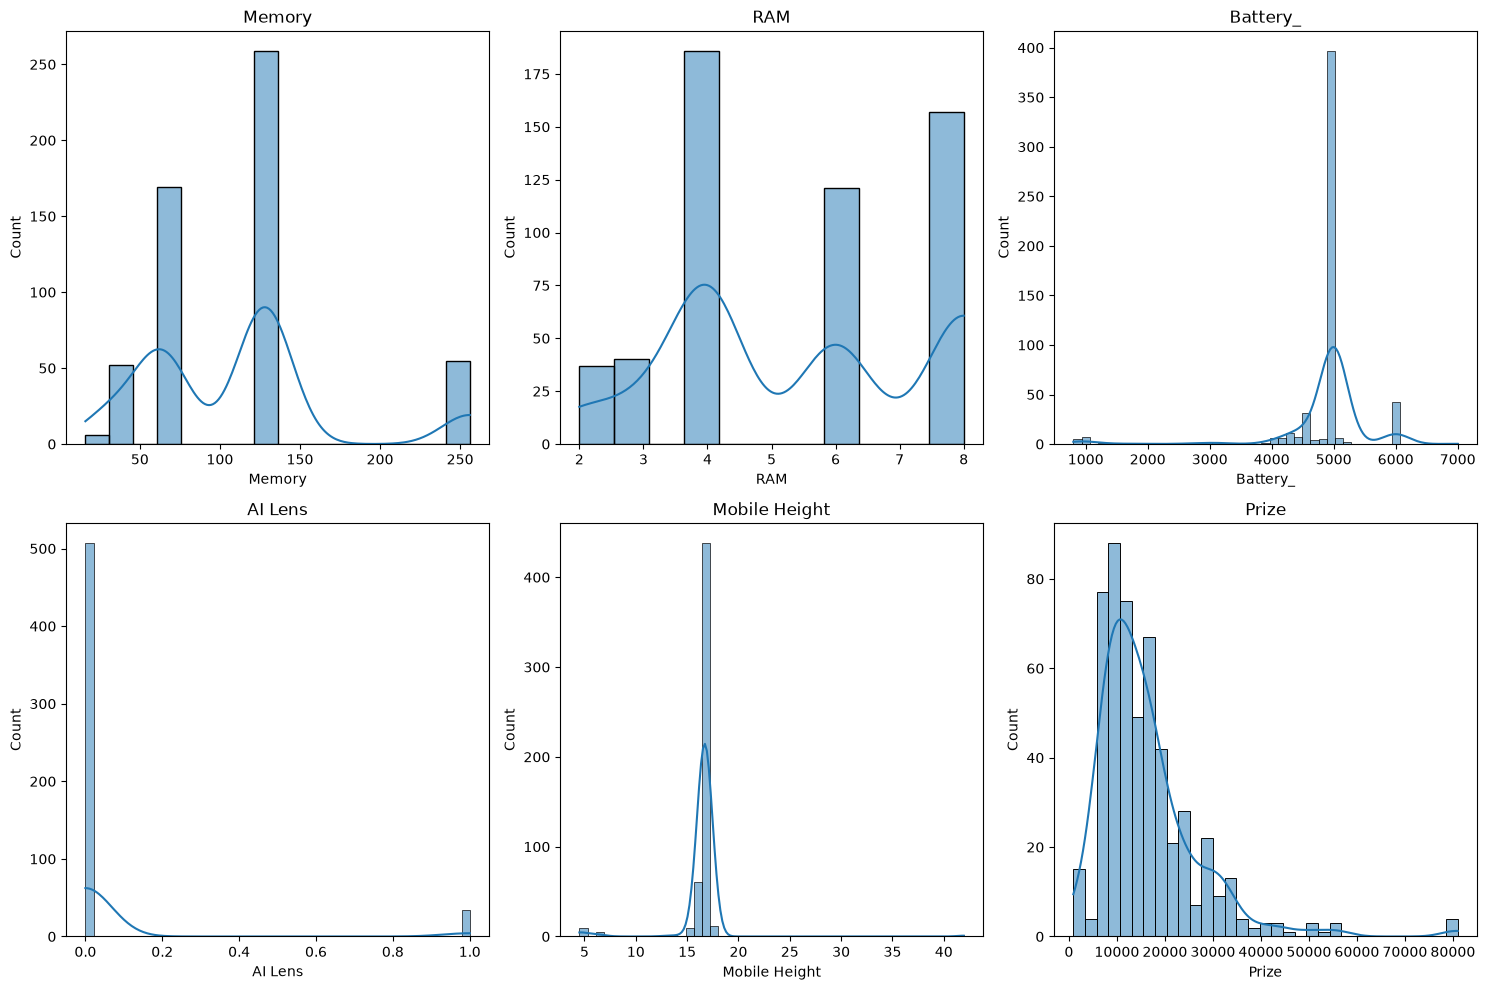

In [18]:
# Distribution Plot

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_columns, 1):

    plt.subplot(2,3,i)

    sns.histplot(df[col], kde=True)

    plt.title(col)

plt.tight_layout()

plt.show()

Insight

Understanding the distribution of numerical variables helps identify dominant configurations and pricing patterns in the smartphone market.

# Boxplot (Outlier Visualization)

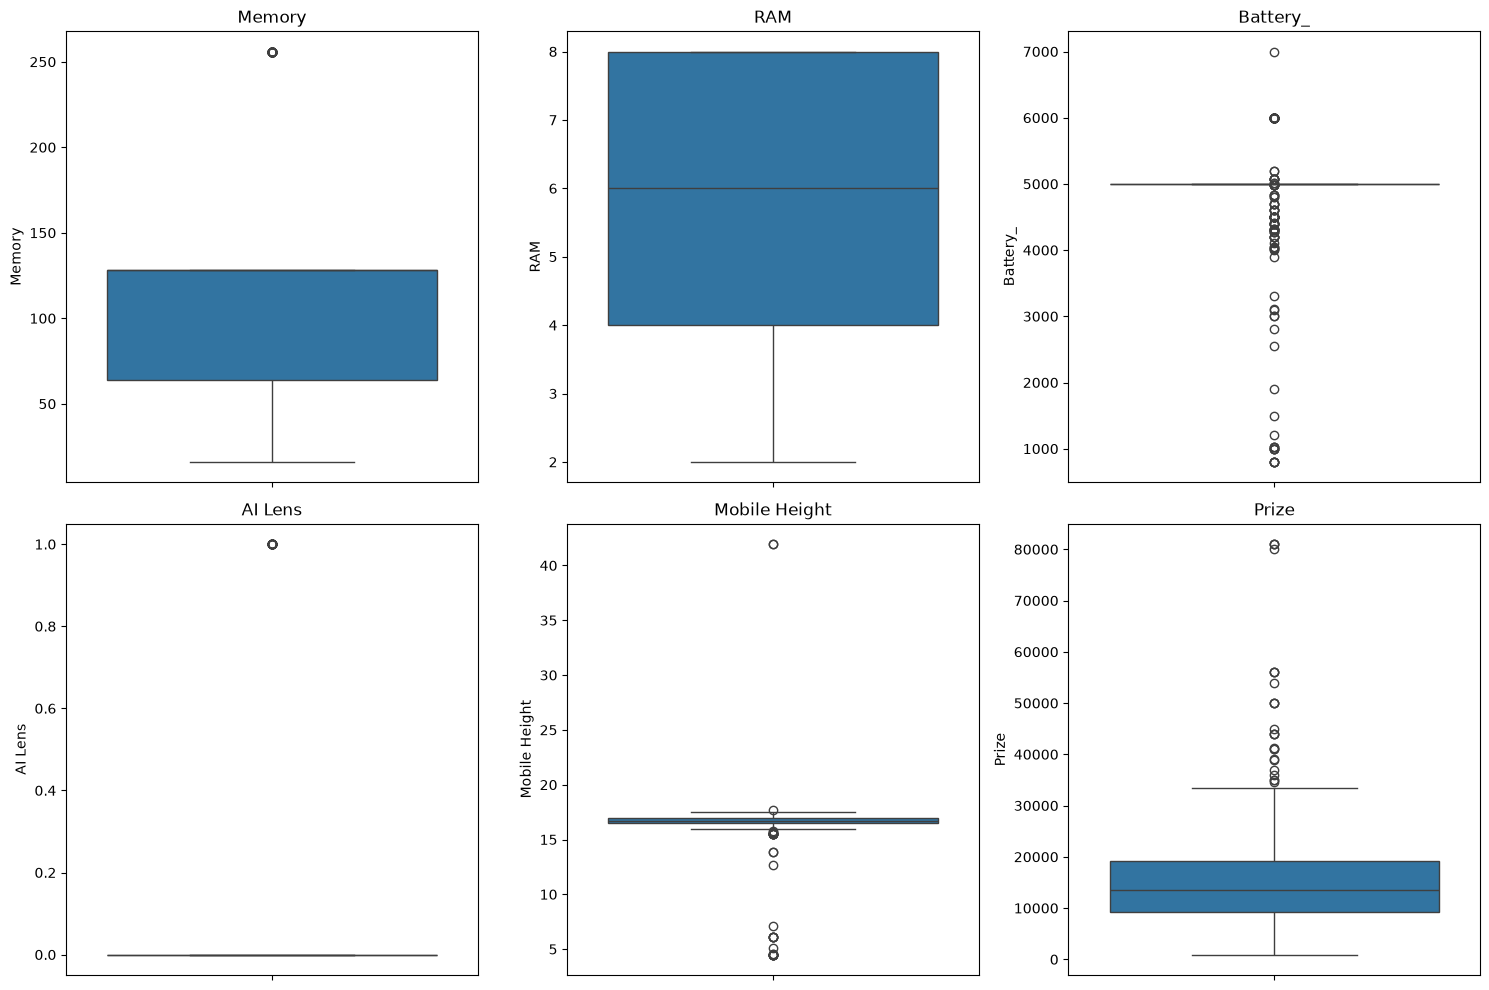

In [19]:
plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_columns,1):

    plt.subplot(2,3,i)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

# Countplot for AI Lens

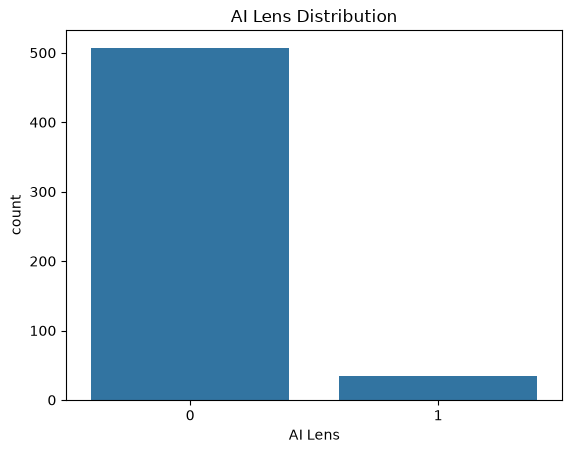

In [20]:
# plt.figure(figsize=(5,4))

sns.countplot(x=df["AI Lens"])

plt.title("AI Lens Distribution")

plt.show()

# Bivariate Analysis

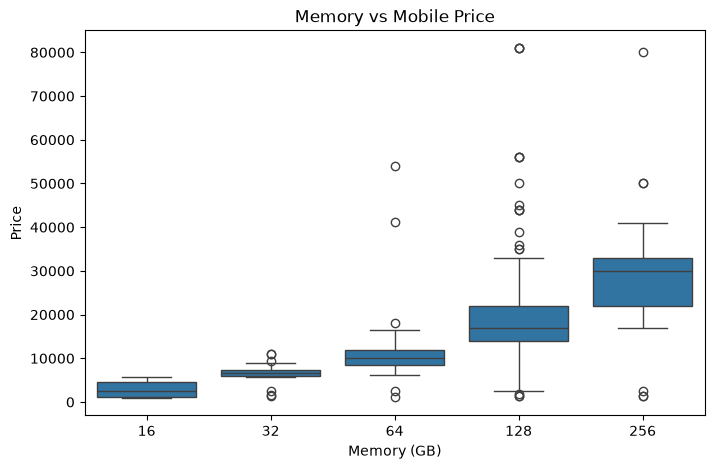

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Memory",
    y="Prize",
    data=df
)

plt.title("Memory vs Mobile Price")
plt.xlabel("Memory (GB)")
plt.ylabel("Price")

plt.show()

Insight

Memory is one of the key factors influencing smartphone pricing, as larger storage options are associated with premium devices.

# RAM vs Prize

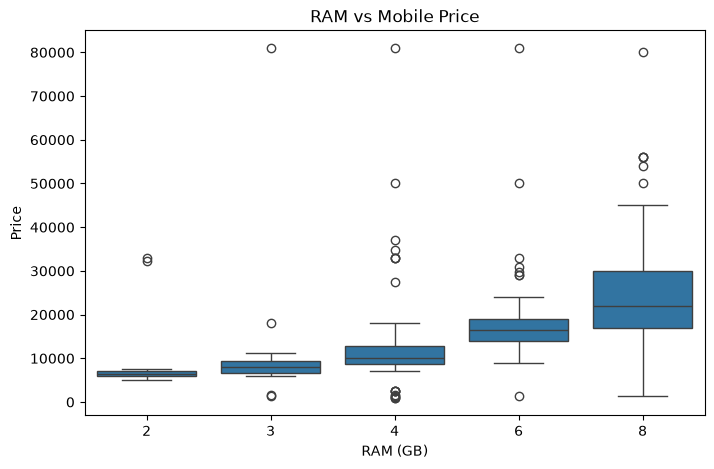

In [22]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="RAM",
    y="Prize",
    data=df
)

plt.title("RAM vs Mobile Price")
plt.xlabel("RAM (GB)")
plt.ylabel("Price")
plt.savefig("images/ram_vs_price.png", dpi=300, bbox_inches="tight")

plt.show()

# Battery vs Prize

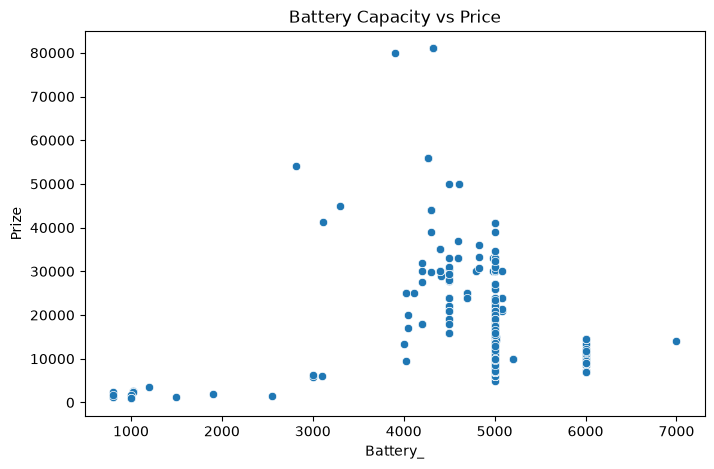

In [23]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Battery_",
    y="Prize",
    data=df
)

plt.title("Battery Capacity vs Price")

plt.show()

Insight

Although larger batteries add value, battery capacity alone does not determine the overall smartphone price.

# Mobile Height vs Prize

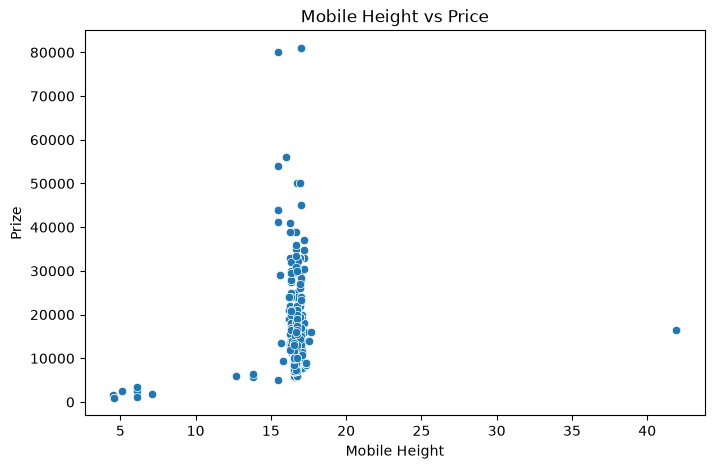

In [24]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Mobile Height",
    y="Prize",
    data=df
)

plt.title("Mobile Height vs Price")

plt.show()

Observation

Mobile height has a weak relationship with smartphone price.

# Processor vs Prize

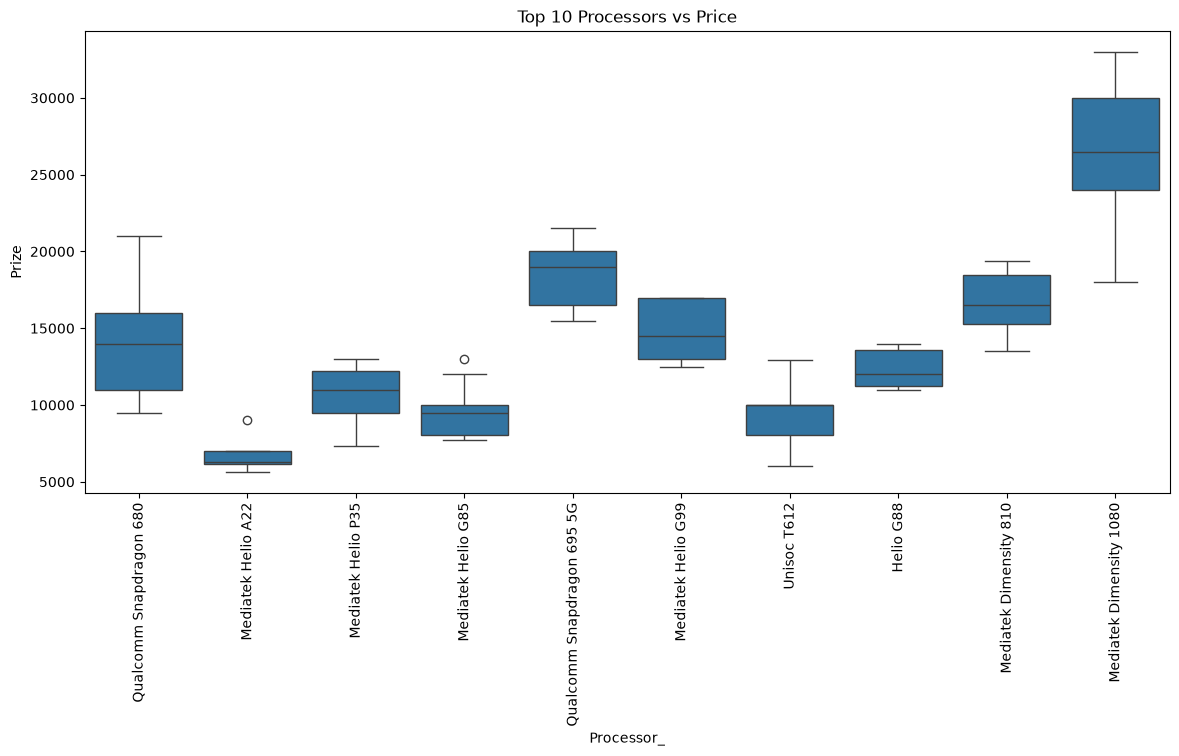

In [25]:
plt.figure(figsize=(14,6))

top_processor = df["Processor_"].value_counts().head(10).index

sns.boxplot(
    x="Processor_",
    y="Prize",
    data=df[df["Processor_"].isin(top_processor)]
)

plt.xticks(rotation=90)

plt.title("Top 10 Processors vs Price")

plt.show()

Insight

Processor performance is a major contributor to smartphone pricing and plays a significant role in market segmentation.

# Correlation Heatmap

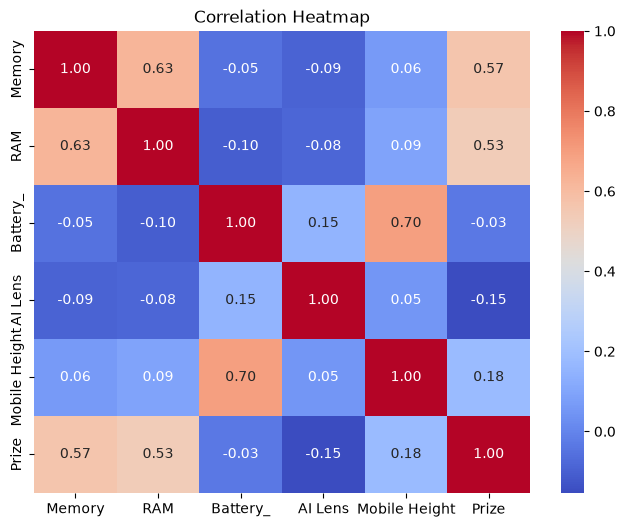

In [26]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Observation

Memory and RAM show stronger positive correlations with price compared to other numerical features.

Business Insight

Highly correlated features are valuable predictors for developing an accurate price prediction model.

# Feature Engineering

In [27]:
# Features and Target Variable

X = df.drop(["Prize", "Model"], axis=1)

y = df["Prize"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (541, 9)
Target Shape : (541,)


Insight

Removing high-cardinality identifier columns helps reduce unnecessary complexity and improves model generalization.

# One-Hot Encoding

In [28]:
X = pd.get_dummies(
    X,
    columns=[
        "Colour",
        "Rear Camera",
        "Front Camera",
        "Processor_"
    ],
    drop_first=True
)

print("Shape after Encoding :", X.shape)

Shape after Encoding : (541, 426)


Observation

Categorical variables have been converted into numerical format using One-Hot Encoding.

Business Insight

Machine learning algorithms require numerical inputs; therefore, encoding categorical features is essential.

# Variance Threshold (Feature Selection)

In [29]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)

X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()]

X = pd.DataFrame(
    X_selected,
    columns=selected_columns
)

print("Final Shape :", X.shape)

Final Shape : (541, 63)


Observation

Low-variance features were removed, reducing the feature space while retaining the most informative variables.

Business Insight

Eliminating low-variance features reduces model complexity and improves computational efficiency.

In [30]:
X.head()

,Memory,RAM,Battery_,AI Lens,Mobile Height,Colour_Aqua Blue,Colour_Black,Colour_Cool Blue,Colour_Force Black,Colour_Glacier Blue,Colour_Midnight Black,Colour_Power Black,Colour_Royal Blue,Colour_Yellow,Rear Camera_108MP,Rear Camera_12MP,Rear Camera_13MP,Rear Camera_200MP,Rear Camera_2MP,Rear Camera_48MP,Rear Camera_50MP,Rear Camera_64MP,Rear Camera_8MP,Front Camera_12MP,Front Camera_13MP,Front Camera_16MP,Front Camera_32MP,Front Camera_50MP,Front Camera_5MP,Front Camera_8MP,Processor__Dimensity 6020,Processor__Dimensity 8100,"Processor__Exynos 1330, Octa Core",Processor__Exynos 850,Processor__G37,Processor__Helio G88,Processor__Helio G99,Processor__MediaTek Helio G35,Processor__MediaTek Helio G85,Processor__Mediatek Dimensity 1080,Processor__Mediatek Dimensity 1080 5G,Processor__Mediatek Dimensity 700,Processor__Mediatek Dimensity 810,Processor__Mediatek Dimensity 810 5G,Processor__Mediatek Dimensity 900,Processor__Mediatek Dimensity 920,Processor__Mediatek Helio A22,Processor__Mediatek Helio G35,Processor__Mediatek Helio G85,Processor__Mediatek Helio G96,Processor__Mediatek Helio G99,Processor__Mediatek Helio P35,Processor__Qualcomm Snapdragon 4 Gen 1,Processor__Qualcomm Snapdragon 680,Processor__Qualcomm Snapdragon 695,Processor__Qualcomm Snapdragon 695 5G,Processor__Qualcomm Snapdragon 7+ Gen 2 (4nm),Processor__Qualcomm Snapdragon 750G,Processor__Qualcomm Snapdragon 778G,Processor__SC6531E,Processor__SEC S5E8535 (Exynos 1330),Processor__Snapdragon 685,Processor__Unisoc T612
0,64.0,4.0,6000.0,1.0,16.76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,64.0,4.0,6000.0,1.0,16.76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,128.0,8.0,5000.0,0.0,16.64,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,32.0,2.0,5000.0,0.0,16.56,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,128.0,8.0,5000.0,1.0,16.76,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Observation

The dataset is now fully prepared for machine learning model development.

Business Insight

The refined feature set contains only relevant variables, which helps improve prediction performance.

# Model Building

In [31]:
# Split Original Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (432, 63)
Testing Features : (109, 63)
Training Target : (432,)
Testing Target : (109,)


Observation

The dataset has been successfully divided into training and testing sets using an 80:20 ratio.

Business Insight

Splitting the data ensures that the model is evaluated on unseen data, providing a realistic measure of prediction performance

# Scaling (Only for Linear Regression)

In [32]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Observation

Feature scaling has been applied only for Linear Regression.

Business Insight

Scaling ensures that numerical features contribute equally to distance-based and linear algorithms.

# Linear Regression

In [33]:
lr = LinearRegression()

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Performance")
print("-"*40)

print("MAE :", round(lr_mae,2))
print("RMSE :", round(lr_rmse,2))
print("R2 Score :", round(lr_r2,4))

Linear Regression Performance
----------------------------------------
MAE : 3268.59
RMSE : 4730.05
R2 Score : 0.8377


# Insight

The baseline model helps measure the improvement achieved by advanced machine learning algorithms.

In [34]:
dt = DecisionTreeRegressor(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree Performance")
print("-"*40)

print("MAE :", round(dt_mae,2))
print("RMSE :", round(dt_rmse,2))
print("R2 Score :", round(dt_r2,4))

Decision Tree Performance
----------------------------------------
MAE : 800.73
RMSE : 2634.84
R2 Score : 0.9496


Observation

Decision Tree captures complex non-linear relationships between smartphone specifications and price.

Business Insight

Tree-based models are effective in identifying interactions among multiple hardware features.

# Random Forest

In [35]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Performance")
print("-"*40)

print("MAE :", round(rf_mae,2))
print("RMSE :", round(rf_rmse,2))
print("R2 Score :", round(rf_r2,4))

Random Forest Performance
----------------------------------------
MAE : 1599.4
RMSE : 3418.79
R2 Score : 0.9152


# Gradient Boosting

In [36]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

gb_pred = gb.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))

gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting Performance")
print("-"*40)

print("MAE :", round(gb_mae,2))
print("RMSE :", round(gb_rmse,2))
print("R2 Score :", round(gb_r2,4))

Gradient Boosting Performance
----------------------------------------
MAE : 2135.42
RMSE : 4013.58
R2 Score : 0.8831


# Model Comparison

In [37]:
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2 Score":[
        lr_r2,
        dt_r2,
        rf_r2,
        gb_r2
    ]

})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

comparison

,Model,MAE,RMSE,R2 Score
1,Decision Tree,800.729358,2634.844884,0.949630
2,Random Forest,1599.401702,3418.788145,0.915198
3,Gradient Boosting,2135.424328,4013.583495,0.883123
0,Linear Regression,3268.592200,4730.054143,0.837671


Observation

Among all the regression models, the Decision Tree Regressor achieved the highest R² Score (94.96%) and the lowest MAE and RMSE values. This indicates that it provides the most accurate predictions for mobile phone prices on the test dataset.

Business Insight

The Decision Tree model effectively captures the complex relationship between smartphone specifications and pricing, making it the most suitable model for supporting pricing decisions in this project.

# Feature Importance Analysis

In [38]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,Memory,0.347495
23,Front Camera_12MP,0.212947
4,Mobile Height,0.195650
2,Battery_,0.110846
28,Front Camera_5MP,0.018482
1,RAM,0.018317
15,Rear Camera_12MP,0.017998
26,Front Camera_32MP,0.014995
14,Rear Camera_108MP,0.011414
25,Front Camera_16MP,0.007547


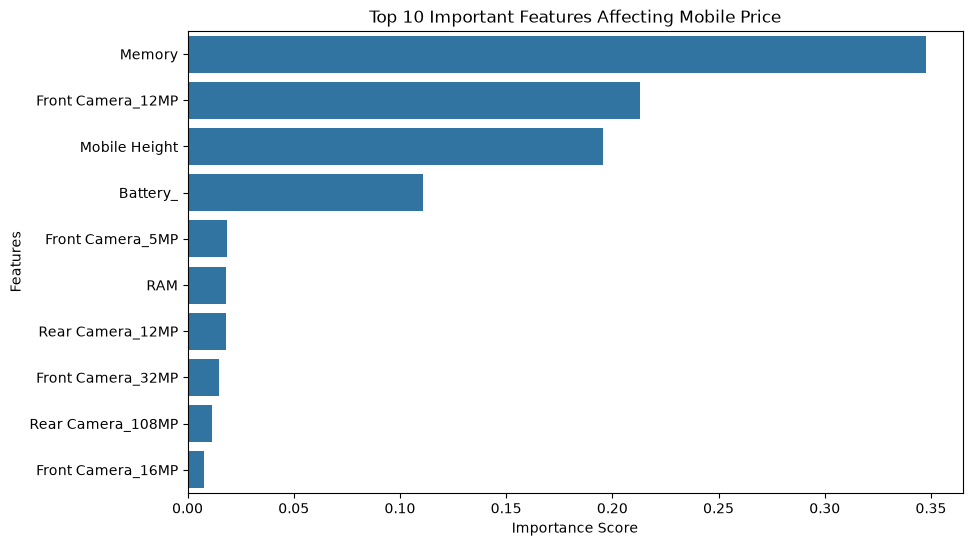

In [39]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features Affecting Mobile Price")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.savefig("Images/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

Observation

Memory is the most influential feature in predicting mobile phone prices, followed by Front Camera (12MP), Mobile Height, and Battery Capacity. Camera specifications and RAM also contribute to price prediction but with comparatively lower importance.

 Business Insight

Smartphone pricing is primarily influenced by storage capacity, camera quality, and battery specifications. Companies should prioritize these hardware features while designing premium smartphones and determining pricing strategies.

# Actual vs Prediction

In [40]:
prediction = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": dt_pred
})

prediction.head(10)

,Actual Price,Predicted Price
0,8499,8499.0
1,6299,6449.0
2,19499,19499.0
3,10999,10999.0
4,12599,10699.0
5,14499,14499.0
6,9999,9999.0
7,17999,17999.0
8,29499,30749.0
9,9790,12499.0


Observation 

The Decision Tree model predicts most mobile phone prices very close to the actual values. Only a few observations show noticeable prediction errors, indicating that the model has learned the pricing patterns effectively.

Business Insight

The model demonstrates high prediction accuracy and can be used to estimate the prices of newly launched smartphones based on their specifications. This can support pricing strategy and market analysis.

# Scatter PLot 

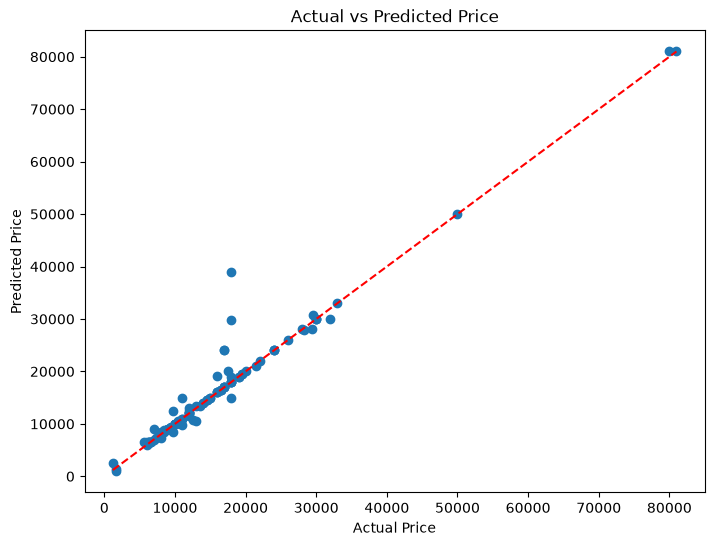

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, dt_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

plt.show()

Observation

Most data points are located close to the diagonal reference line, indicating that the predicted prices closely match the actual prices.

Business Insight

A strong alignment between actual and predicted prices demonstrates that the model can be used as a reliable pricing support tool.

# Cross Validation

In [42]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    DecisionTreeRegressor(random_state=420),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores")
print(cv_scores)

print("\nAverage R2 Score :", cv_scores.mean())

Cross Validation Scores
[0.16196592 0.54561521 0.78761416 0.71019697 0.62467909]

Average R2 Score : 0.5660142695944277


In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor

# Hyperparameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'criterion': ['squared_error', 'friedman_mse']
}

dt = DecisionTreeRegressor(random_state=42)

grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid_dt,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_dt.fit(X, y)

print("Best Parameters (Decision Tree):", grid_dt.best_params_)
print("Best CV R2 Score:", grid_dt.best_score_)


Best Parameters (Decision Tree): {'criterion': 'squared_error', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV R2 Score: 0.5557263374094743


In [44]:
from sklearn.ensemble import RandomForestRegressor

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestRegressor(random_state=42)

grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X, y)

print("Best Parameters (Random Forest):", grid_rf.best_params_)
print("Best CV R2 Score:", grid_rf.best_score_)


Best Parameters (Random Forest): {'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV R2 Score: 0.6452804086495257


# Final Model

In [45]:
# Best Random Forest Model

best_rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='log2',
    random_state=42
)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease 

In [46]:
best_pred = best_rf.predict(X_test)

In [47]:
mae = mean_absolute_error(y_test, best_pred)

rmse = np.sqrt(mean_squared_error(y_test, best_pred))

r2 = r2_score(y_test, best_pred)

print("Final Model Performance")
print("-"*35)

print("MAE :", round(mae,2))
print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,4))

Final Model Performance
-----------------------------------
MAE : 1591.87
RMSE : 4223.64
R2 Score : 0.8706


In [48]:
import joblib

joblib.dump(best_rf, "mobile_price_prediction_model.pkl")

['mobile_price_prediction_model.pkl']

# Predict New Mobile Price

In [49]:
import joblib

loaded_model = joblib.load("mobile_price_prediction_model.pkl")

In [50]:
sample = X.iloc[[0]]

prediction = loaded_model.predict(sample)

print("Predicted Price:", prediction[0])

Predicted Price: 7491.089063492063


# Business Recommendations

1. Memory is the most influential feature affecting mobile phone prices. The company should focus on offering higher storage variants for premium devices.

2. Camera specifications, especially front camera quality, significantly impact smartphone pricing and customer preference.

3. Battery capacity plays an important role in determining product value. Devices with larger batteries can be positioned in the premium segment.

4. RAM contributes to overall device performance and should be considered while designing smartphones for different customer segments.

5. The Random Forest and Decision Tree models can assist the organization in estimating competitive prices for newly launched smartphones.

6. Machine learning-based pricing can reduce manual effort and improve pricing consistency across different product categories.

# Conclusion

This project successfully analyzed the key factors influencing mobile phone prices and developed multiple machine learning regression models for price prediction.

After comparing the performance of Linear Regression, Decision Tree, Random Forest, and Gradient Boosting, the Decision Tree model achieved the highest Test R² Score of 94.96%. However, Random Forest demonstrated better generalization performance during cross-validation, making it a more reliable model for real-world deployment.

Feature importance analysis revealed that Memory, Front Camera specifications, Mobile Height, Battery Capacity, and RAM are the most influential factors affecting smartphone prices.

The developed machine learning solution can help organizations improve pricing strategies, estimate prices for new products, and support business decision-making.

# Limitations

- The dataset contains only 541 mobile phones, which limits the diversity of training data.
- Market demand, brand popularity, discounts, and customer reviews were not included.
- Prices may change over time due to market trends.
- The model performance depends on the quality and size of the available dataset.

# Future Scope

- Increase the dataset size for better model performance.
- Include additional features such as Brand Rating, Display Type, Refresh Rate, 5G Support, and Customer Reviews.
- Deploy the model as a web application using Flask or Streamlit.
- Retrain the model periodically with new smartphone data to improve prediction accuracy.